In [1]:
!pip install plotly -q
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.figsize': (16, 8),    
    'figure.facecolor': 'white',    
    'figure.autolayout': True,     
})

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_contour, plot_slice
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler

from xgboost import XGBRegressor

import shap

# from catboost import CatBoostRegressor
# from catboost.utils import get_gpu_device_count


# import lightgbm as lgb
# from lightgbm import LGBMRegressor
import warnings

warnings.filterwarnings("ignore")

In [3]:
formula_train = pd.read_csv("/kaggle/input/critical-temperature-of-superconductors/formula_train.csv")
formula_test = pd.read_csv("/kaggle/input/critical-temperature-of-superconductors/formula_test.csv")

train = pd.read_csv("/kaggle/input/critical-temperature-of-superconductors/train.csv")
test = pd.read_csv("/kaggle/input/critical-temperature-of-superconductors/test.csv")

In [4]:
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [5]:
print(f"Na: {train.isna().sum()[train.isna().sum() > 0]}")
print(f"Na: {formula_train.isna().sum()[formula_train.isna().sum() > 0]}")

Na: Series([], dtype: int64)
Na: Series([], dtype: int64)


In [6]:
formula_train.head()

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,22.0,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,23.0,Ba0.3La1.7Cu1O4


In [7]:
combined = pd.concat([formula_train, formula_test], axis=0)
zero_cols = list(combined.columns[(combined == 0).all()]) + ["material"]

formula_train.drop(columns=zero_cols, inplace=True)
formula_train.drop(columns="critical_temp", inplace=True)
formula_test.drop(columns=zero_cols, inplace=True)

In [8]:
train_sum = (formula_train.sum() / formula_train.shape[0]).reset_index()
test_sum = (formula_test.sum() / formula_test.shape[0]).reset_index() 

train_sum.columns = ["element", "total"]
test_sum.columns = ["element", "total"]

train_sum["dataset"] = "train"
test_sum["dataset"] = "test"

sum_df = pd.concat([train_sum, test_sum], ignore_index=True)

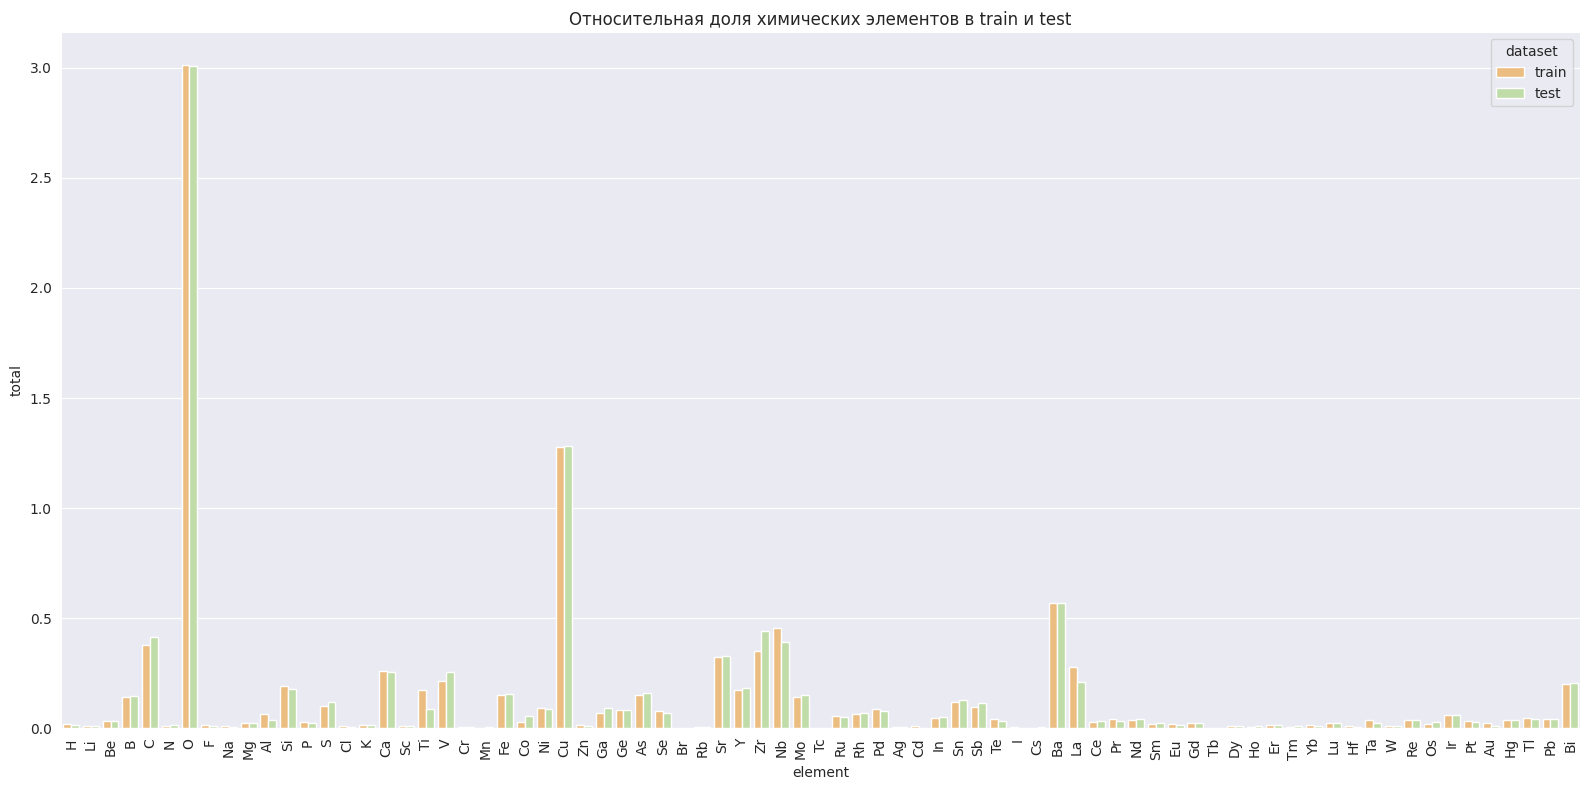

In [9]:
sns.barplot(data=sum_df, x="element", y="total", hue="dataset", palette="Spectral")
plt.xticks(rotation=90)
plt.title("Относительная доля химических элементов в train и test")
plt.show()

In [10]:
discrete = [
    "number_of_elements",
    "range_Valence"
]

num_param = [
    col for col in test.columns if col not in discrete
]

In [11]:
train['dataset'] = 'train'
test['dataset'] = 'test'

visualisation_df = pd.concat([train, test], axis=0)

train.drop(columns='dataset', inplace=True)
test.drop(columns='dataset', inplace=True)

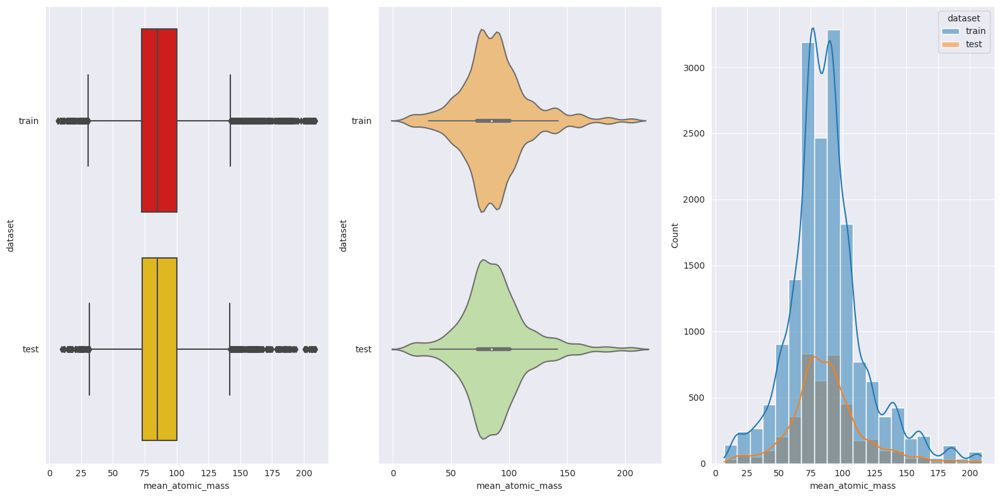

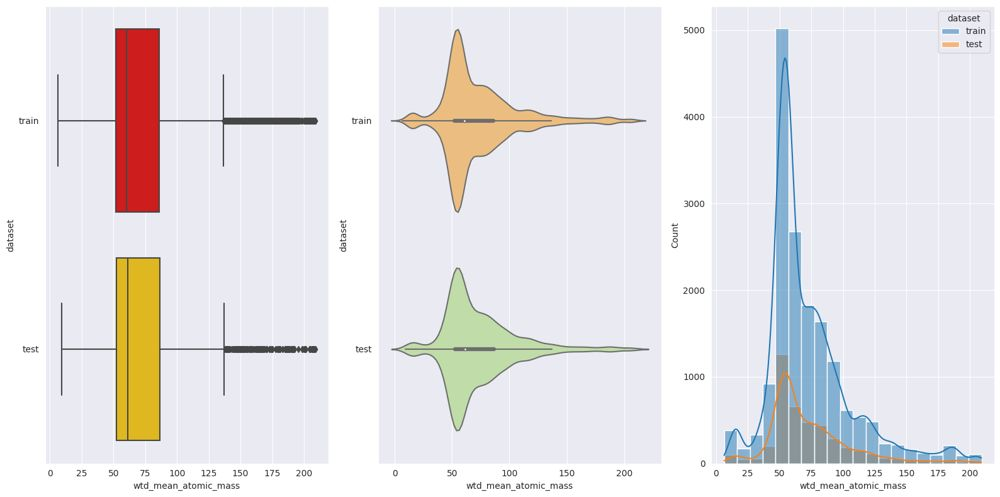

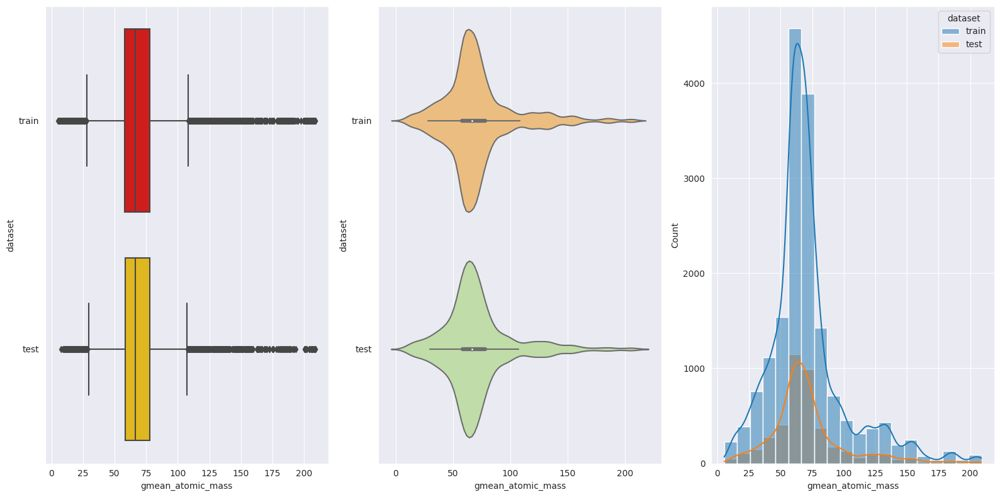

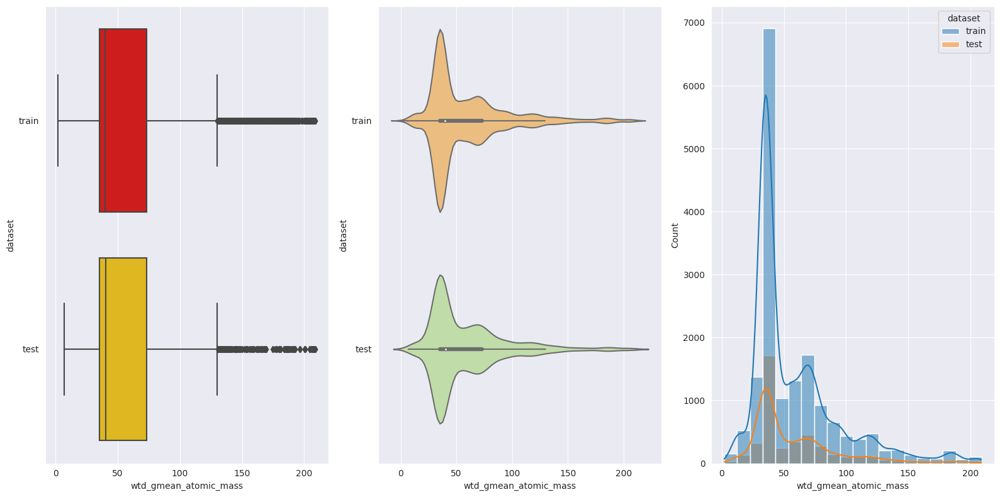

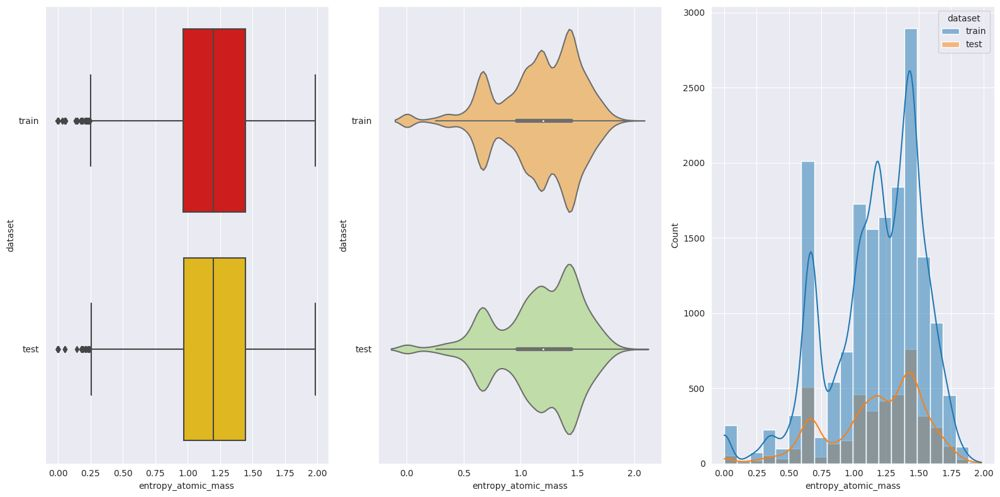

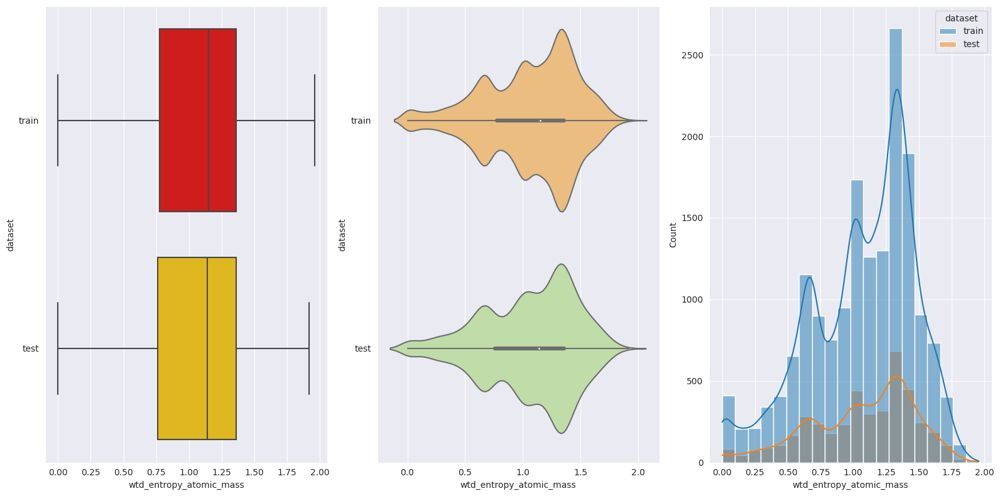

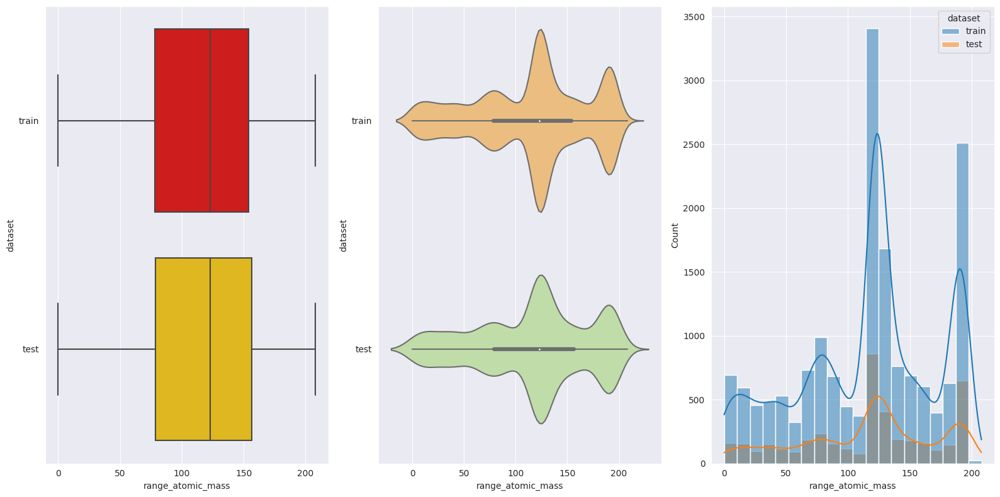

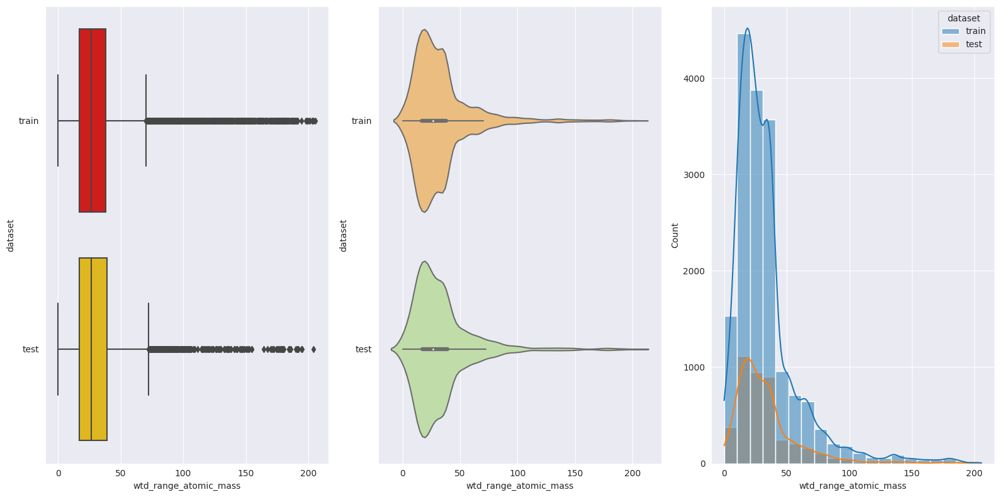

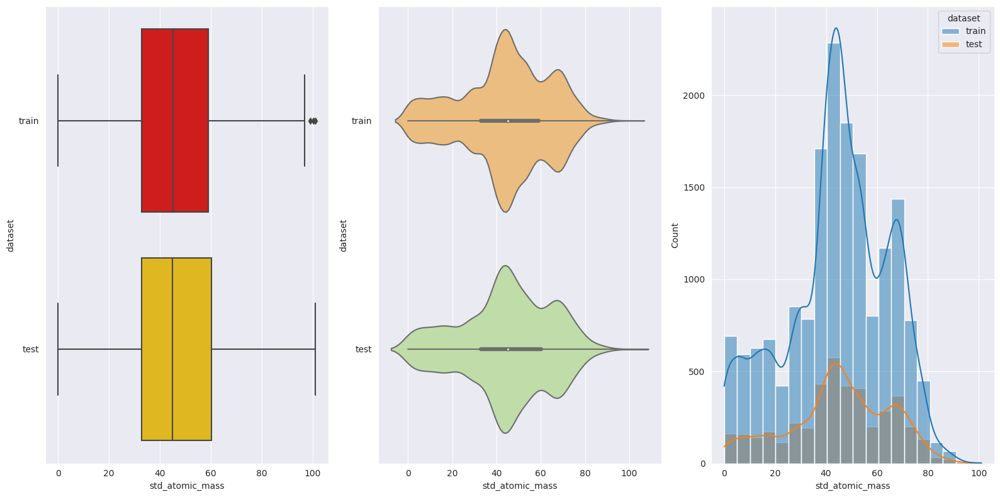

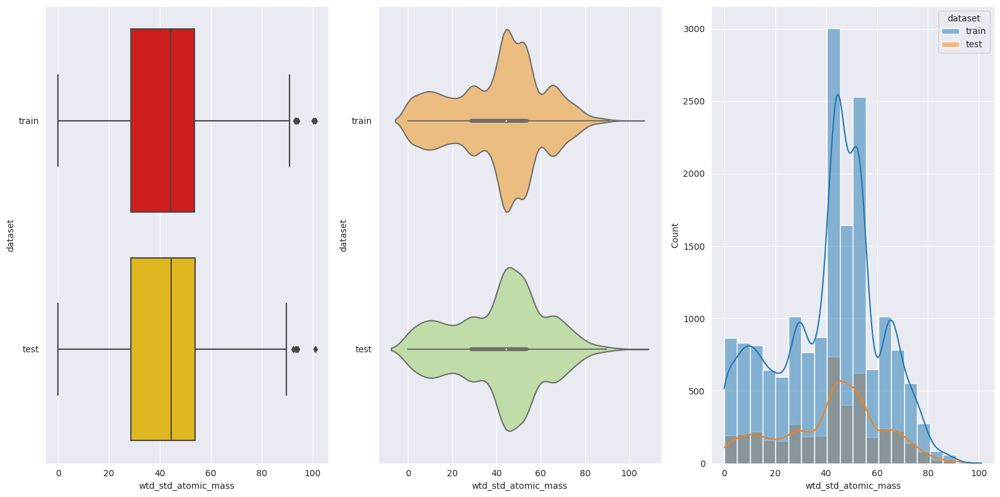

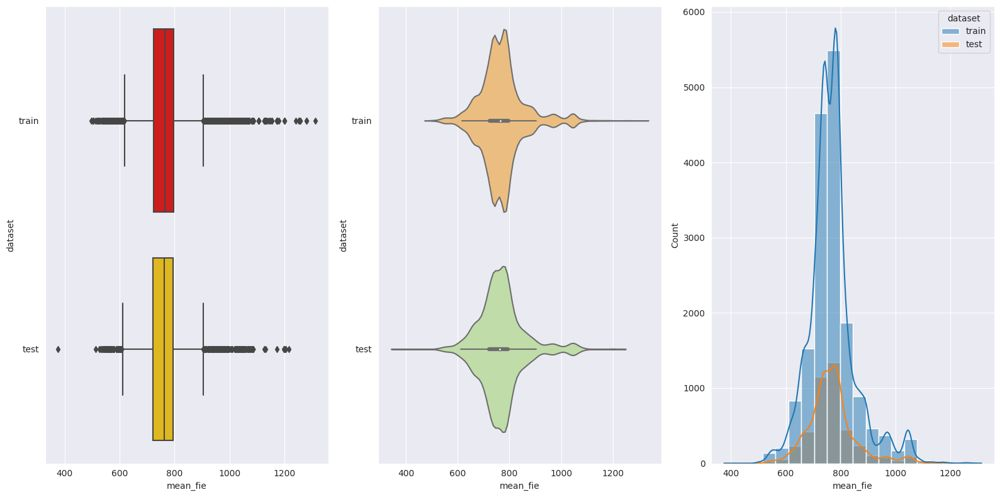

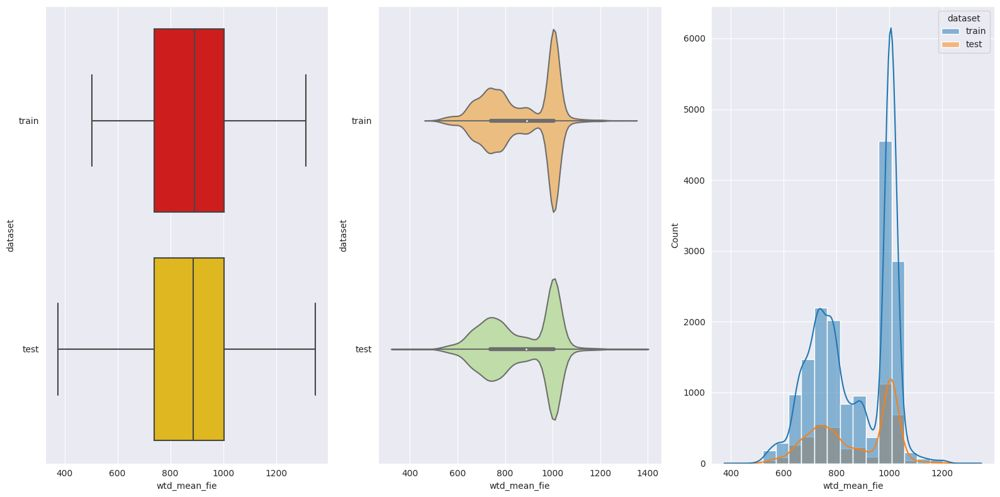

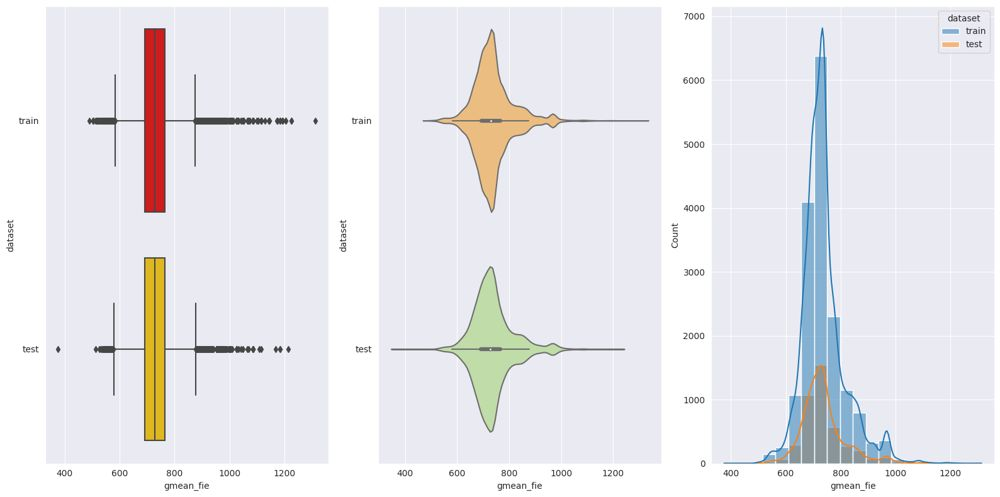

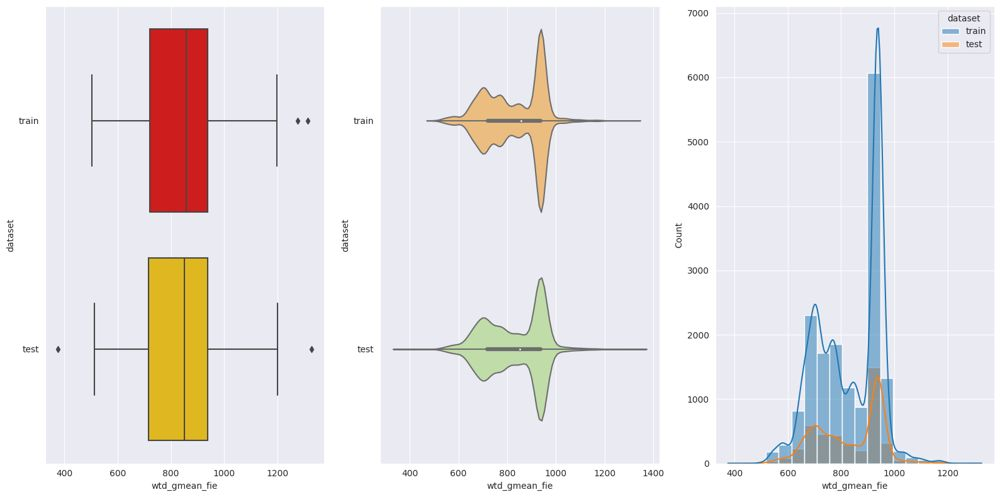

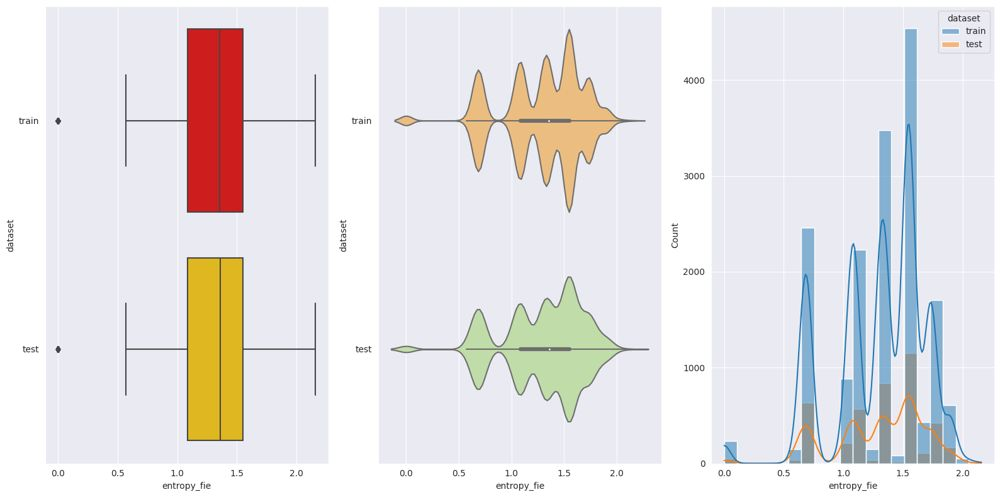

In [12]:
for features in num_param[:15]:
    fig, ax = plt.subplots(nrows=1, ncols=3)
    sns.boxplot(data=visualisation_df, y='dataset', x=features, ax=ax[0], orient='h', palette='hot')
    sns.violinplot(data=visualisation_df, y='dataset', x=features, ax=ax[1], palette='Spectral')
    sns.histplot(data=visualisation_df, hue='dataset', x=features, ax=ax[2], kde=True, bins=20)
    plt.show()

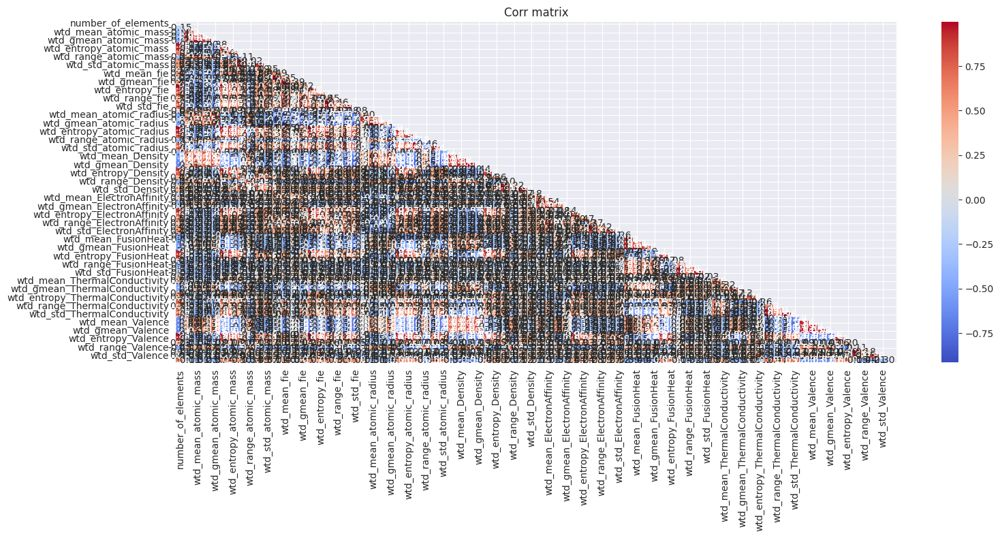

In [13]:
correlation_matrix = train.corr(numeric_only=True) 
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', mask=mask)
plt.title('Corr matrix')
plt.show()

In [14]:
X = train.drop(columns="critical_temp")
target = train["critical_temp"]

In [15]:
# scaler = RobustScaler().set_output(transform="pandas")

# scaler.fit(X)

# X = scaler.transform(X)
# test = scaler.transform(test)

In [16]:
X = pd.concat([X, formula_train], axis=1)
test = pd.concat([test, formula_test], axis=1)

In [17]:
def objective_xgb(trial):
    max_depth=trial.suggest_int("max_depth", 5, 8)
    n_estimators=trial.suggest_int("n_estimators", 120, 200)
    min_child_weight=trial.suggest_int("min_child_weight", 1, 100)
    subsample=trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0)
    reg_alpha=trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda=trial.suggest_float("reg_lambda", 0, 1)
    

    model = XGBRegressor(tree_method = "hist", 
        device = "cuda",
        random_state=42,
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda
    )

    scores = cross_val_score(model, 
        X, 
        target, 
        cv=3,  
        scoring="neg_mean_squared_error"  
    )

    rmse_scores = np.sqrt(-scores)  
    
    return rmse_scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective_xgb, n_trials=50)

[I 2025-07-28 12:31:38,176] A new study created in memory with name: no-name-528229f8-d644-4404-834a-5912816df28f
[I 2025-07-28 12:31:41,886] Trial 0 finished with value: 14.001114120922376 and parameters: {'max_depth': 7, 'n_estimators': 197, 'min_child_weight': 52, 'subsample': 0.9360338999631455, 'colsample_bytree': 0.9558535880659826, 'reg_alpha': 0.24301932876357213, 'reg_lambda': 0.36321961459811014}. Best is trial 0 with value: 14.001114120922376.
[I 2025-07-28 12:31:43,733] Trial 1 finished with value: 14.014600471605343 and parameters: {'max_depth': 6, 'n_estimators': 121, 'min_child_weight': 49, 'subsample': 0.7050271780192157, 'colsample_bytree': 0.9143714816319741, 'reg_alpha': 0.9860277646834998, 'reg_lambda': 0.5059506957155104}. Best is trial 0 with value: 14.001114120922376.
[I 2025-07-28 12:31:46,115] Trial 2 finished with value: 14.248102108344817 and parameters: {'max_depth': 6, 'n_estimators': 192, 'min_child_weight': 77, 'subsample': 0.962762770899458, 'colsample_b

In [18]:
plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_contour(study, params=["max_depth", "n_estimators"]).show()
plot_slice(study, params=["max_depth", "subsample", "n_estimators"]).show()

In [19]:
model_xgb = XGBRegressor(tree_method = "hist", 
    device = "cuda",
    random_state=42,
    **study.best_trial.params
)

In [20]:
model_xgb.fit(X, 
    target,
    eval_metric="rmse",
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6131819722975888, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=46, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=173,
             n_jobs=None, num_parallel_tree=None, random_state=42, ...)

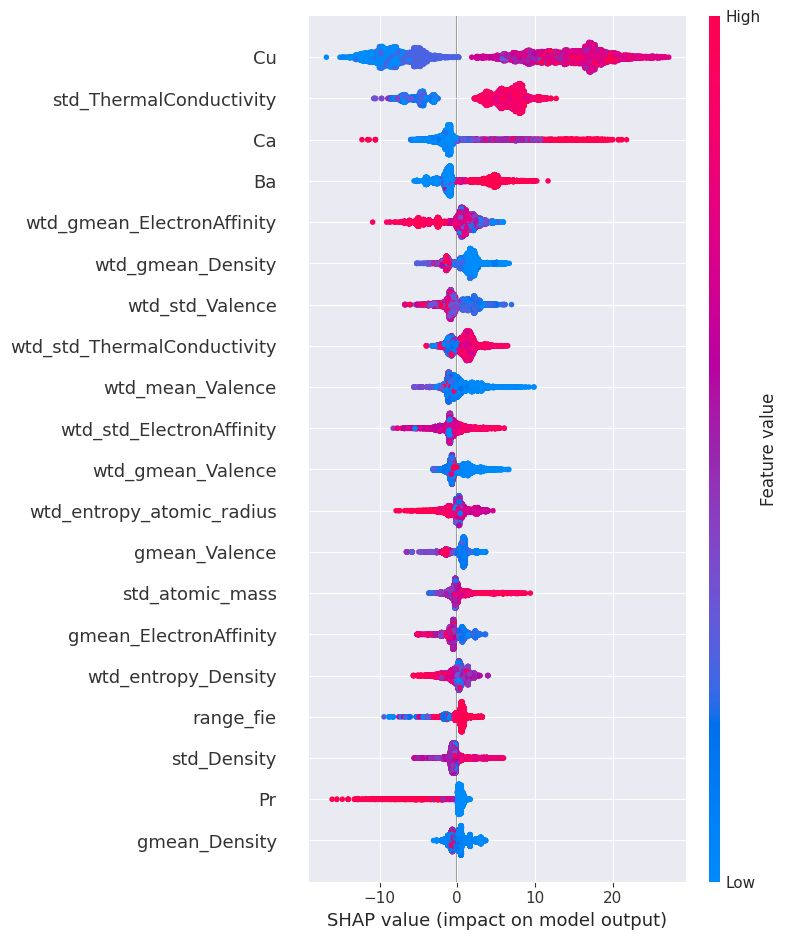

In [21]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X.iloc[:10000, ])

shap.summary_plot(shap_values, X.iloc[:10000, ])

In [22]:
shap.initjs()
print('Correct answer:', target.iloc[2])
shap.force_plot(explainer.expected_value, shap_values[2,:], X.iloc[2,:])

Correct answer: 19.0


In [23]:
pred = model_xgb.predict(test)

In [24]:
submission = pd.DataFrame({
    'index': test.index,
    'critical_temp': pred
})
submission.to_csv('submission.csv', index=False)

In [25]:
submission

,index,critical_temp
0,0,25.827501
1,1,29.838337
2,2,91.703873
3,3,76.622604
4,4,82.243797
...,...,...
4248,4248,22.789623
4249,4249,6.065451
4250,4250,3.169502
4251,4251,2.369926
